In [9]:
import tifffile
import numpy
import matplotlib.pyplot as plt
import numpy as np

from src.utils import ingaas_processing as ip
from src.utils import scanner_processing as scp
import cv2

resize = lambda x: cv2.resize(x, (x.shape[1], 766))
process = lambda x: ip.lin_stretch_img(resize(x), 0.3, 99.7)

In [10]:
dir = "/home/jepero/Work/Code/Scans/Paper_Cloud_Cover/"
scan = tifffile.imread(dir+"scan.tif")
mod_freq = 50
fps = 300.001647

74


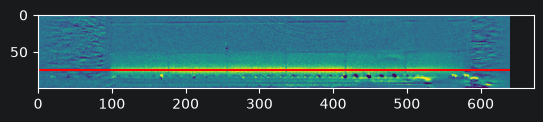

In [11]:
peaks,valleys = scp.get_extrema_scan(scan, 300, 0, f_m=mod_freq, fps=fps)
frame_profile = scan.sum(axis=2)
frame_diffs = frame_profile[peaks] - frame_profile[valleys]
#plt.plot(np.sum(np.abs(frame_diffs), axis=0))
#plt.show()
lom = np.argmax(np.mean(np.abs(frame_diffs), axis=0))
print(lom)
plt.imshow(ip.lin_stretch_img(scan[peaks[200]]-scan[valleys[200]], 0.3, 99.7))
plt.hlines(lom, 0, 640, "r")
plt.show()
signal_high = scan[peaks,lom,:]
signal_low = scan[valleys+2,lom,:]
Bg = scan[valleys,lom,:]
stitch_high = signal_high-Bg
stitch_low = signal_low - Bg

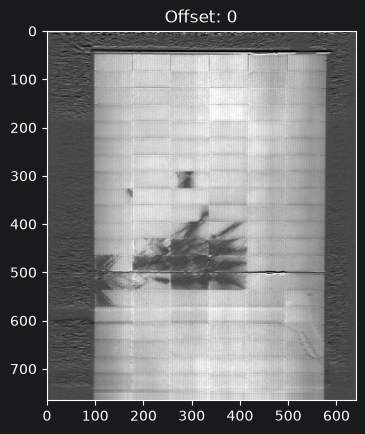

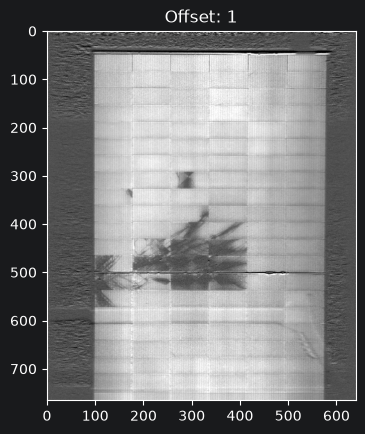

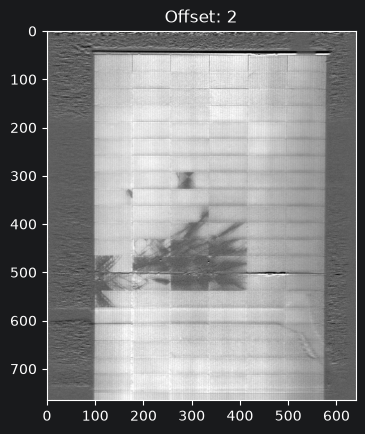

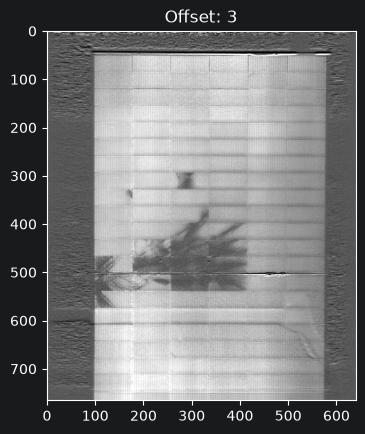

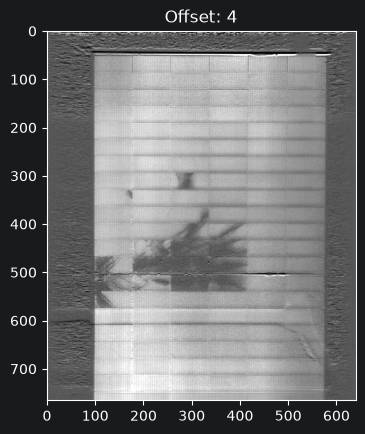

In [12]:
for i in range(0, 5):
    if i == 0:
        signal = scan[peaks, lom, :]
        background = scan[valleys, lom, :]
    if i > 0:
        signal = scan[peaks, lom+i, :]
        background = scan[valleys, lom+i, :]


    plt.imshow(process(signal-background), cmap="gray")
    plt.title(f"Offset: {i}")
    plt.show()

Text(0.5, 1.0, 'Test')

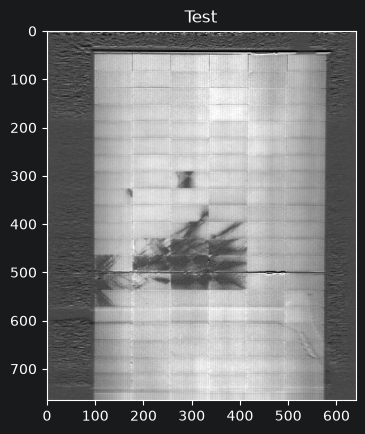

In [13]:
plt.imshow(process(stitch_high), cmap='gray')
plt.title("Test")

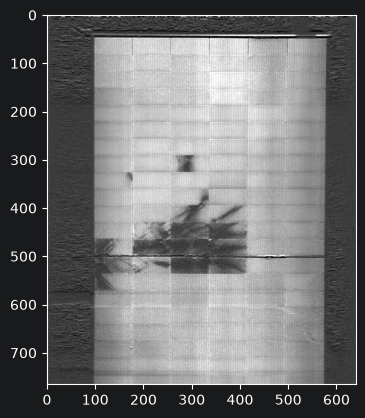

In [14]:
plt.imshow(process(stitch_low), cmap='gray')

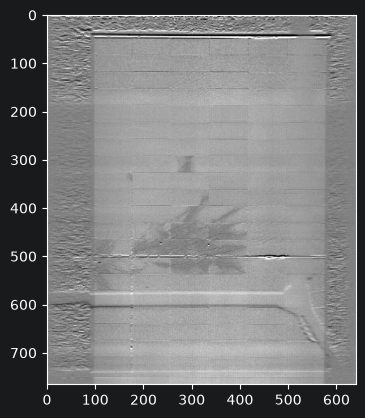

In [15]:
plt.imshow(process(stitch_high-stitch_low), cmap='gray')

0.053162919193521535
0.000797443787902823
0.138888126393075


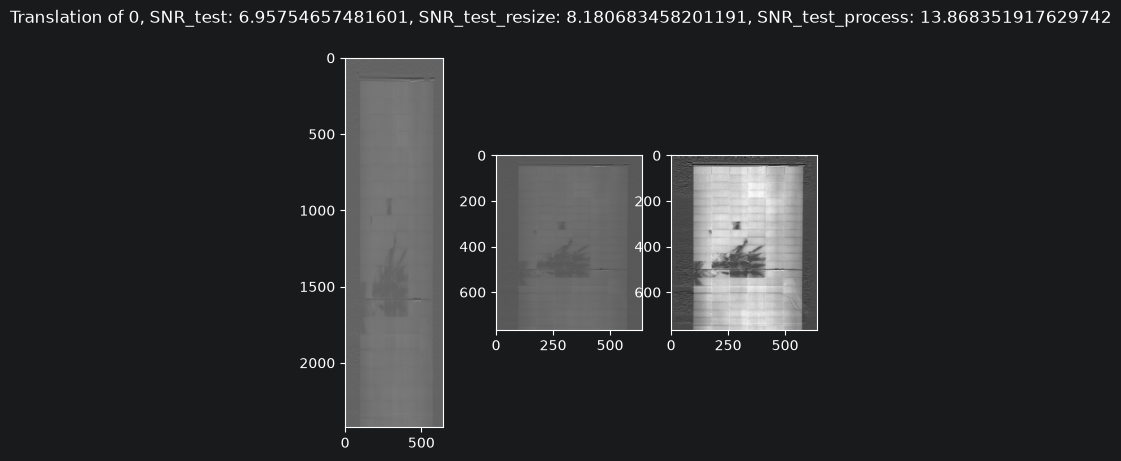

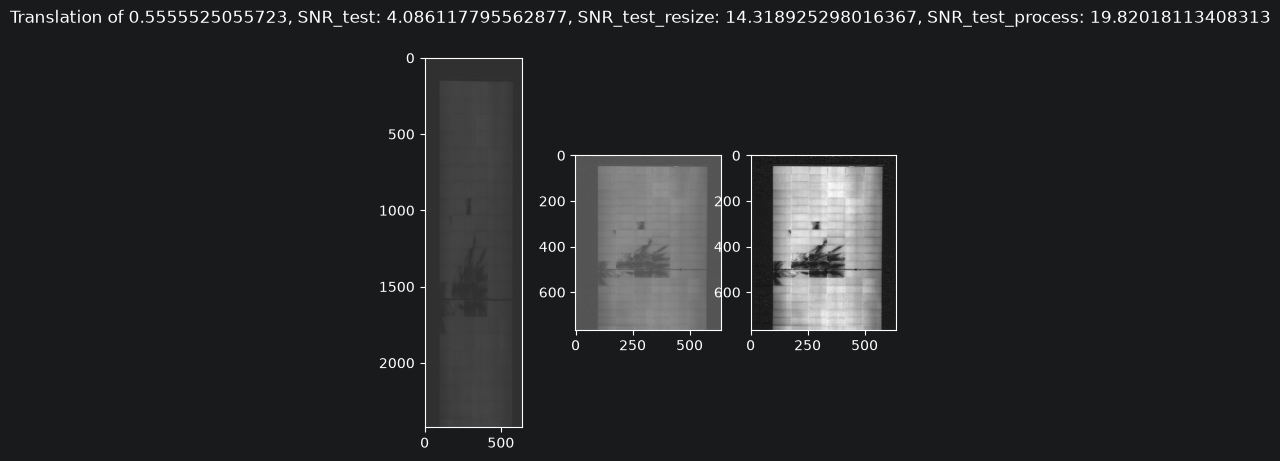

In [27]:
# MATH
H_cam = 1045 #mm
focal = 6 #mm
speed = 2500/60 #mm/sec
pixel_pitch = 15/1000 #mm/pixel

frame_diff_high = np.abs(peaks-valleys).mean() #Frame between signal high and bg
frame_diff_low = 2
#FPS: frames/second
#pixel_pith: um/pixel

#Getting scaling factor
dpf = speed / fps  # mm/frame, on module
# dist_travel/cameraHeight=d/f
#doffset = 200 / H_cam * f  # distance in mm on image plane
dpf_f = dpf / H_cam * focal  # distance per frame in mm on image plane mm/frame
dpf_px = dpf_f / pixel_pitch  # distance per frame in px on image plane

print(dpf_px)
print(dpf_f)
print(dpf)

for ty in [0, 4*dpf]:
    # Define translation values
    tx = 0

    # Create the translation matrix
    translation_matrix = np.float32([
        [1, 0, tx],
        [0, 1, ty]
    ])

    # Get the dimensions of the image
    height, width = Bg.shape[:2]

    # Apply translation
    fig,axes = plt.subplots(1,3)
    Bg_trans = cv2.warpAffine(Bg, translation_matrix, (width, height))
    stitch_trans = signal_high-Bg_trans
    axes[0].imshow(stitch_trans, cmap='gray')
    axes[1].imshow(resize(stitch_trans), cmap='gray')
    axes[2].imshow(process(stitch_trans), cmap='gray')
    fig.suptitle(f"Translation of {ty}, SNR_test: {np.mean(stitch_trans[:, 100:540]) / np.std(stitch_trans[:, 0:75], ddof=1)}, SNR_test_resize: {np.mean(resize(stitch_trans)[:, 100:540]) / np.std(resize(stitch_trans)[:, 0:75], ddof=1)}, SNR_test_process: {np.mean(process(stitch_trans)[:, 100:540]) / np.std(process(stitch_trans)[:, 0:75], ddof=1)}")
    plt.show()

# stitch = signal_high-Bg
# plt.imshow(process(stitch), cmap='gray')
# plt.title(f"No translation, SNR_test: {np.mean(resize(stitch)[:, 100:540]) / np.std(resize(stitch)[:, 0:75],  ddof=1)}")
# plt.show()